In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

1. Load and Explore Dataset

In [4]:
# Load the CSV file - adjust the path to your local file
df = pd.read_csv('C:\\Users\\DELL\\Downloads\\nvd_cves_regression.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())


Dataset Shape: (187, 7)

Columns: ['cve_id', 'base_score', 'year', 'source', 'vuln_status', 'cwe', 'vector_string']

First 5 rows:
          cve_id  base_score  year         source vuln_status             cwe  \
0  CVE-1999-0084         8.4  1990  cve@mitre.org    Deferred   NVD-CWE-Other   
1  CVE-1999-0066         9.8  1995  cve@mitre.org    Deferred   NVD-CWE-Other   
2  CVE-1999-0022         7.8  1996  cve@mitre.org    Deferred   NVD-CWE-Other   
3  CVE-1999-0043         9.8  1996  cve@mitre.org    Deferred   NVD-CWE-Other   
4  CVE-1999-0236         7.5  1997  cve@mitre.org    Deferred  NVD-CWE-noinfo   

                                  vector_string  
0  CVSS:3.1/AV:L/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H  
1  CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H  
2  CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H  
3  CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H  
4  CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to

2. Data Preprocessing

In [10]:
# ==============================
# 2. Data Preprocessing (Alternative Robust Version)
# ==============================
print("Starting Data Preprocessing (Robust Version)...")

# Re-read the CSV with explicit encoding
df = pd.read_csv('nvd_cves_regression.csv', encoding='utf-8')

# Clean column names
df.columns = df.columns.str.strip().str.lower()
print("Original columns:", df.columns.tolist())

# Drop irrelevant columns
columns_to_drop = ['cve_id', 'source']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")

# Drop rows where target is missing
initial_rows = len(df)
df = df.dropna(subset=['base_score'])
print(f"Dropped {initial_rows - len(df)} rows with missing base_score")

# Find vector string column (might be named differently)
vector_col = None
for col in df.columns:
    if 'vector' in col and 'string' in col:
        vector_col = col
        break

if vector_col is None:
    # If no vector_string column, check if it was already dropped or renamed
    print("Available columns:", df.columns.tolist())
    raise ValueError("No vector string column found in the dataset")
else:
    print(f"Using vector column: '{vector_col}'")

# Clean vector strings
df[vector_col] = df[vector_col].astype(str)
df[vector_col] = df[vector_col].str.replace('CVSS:3.1/', '', regex=False)
df[vector_col] = df[vector_col].str.replace(']', '', regex=False)
df[vector_col] = df[vector_col].str.strip()

print("\nSample cleaned vectors:")
for i, vec in enumerate(df[vector_col].head(3)):
    print(f"  Vector {i+1}: {vec}")

# Parse vectors
def parse_vector_robust(vector):
    """Robust CVSS vector parser"""
    if pd.isna(vector) or vector == '':
        return {}
    
    result = {}
    try:
        parts = vector.split('/')
        for part in parts:
            if ':' in part:
                key, value = part.split(':', 1)
                key = key.strip()
                value = value.strip()
                if key and value:  # Only add if both key and value are non-empty
                    result[key] = value
    except Exception as e:
        print(f"Warning: Could not parse vector '{vector}': {e}")
    
    return result

# Apply parsing
print("\nParsing vectors...")
vector_data = df[vector_col].apply(parse_vector_robust)
vector_df = pd.DataFrame(vector_data.tolist())

if not vector_df.empty:
    print(f"Extracted {len(vector_df.columns)} vector features: {vector_df.columns.tolist()}")
    
    # Combine with original dataframe
    df = pd.concat([df, vector_df], axis=1)
    
    # Drop the original vector column
    df = df.drop(columns=[vector_col])
    
    print("\nFinal columns:", df.columns.tolist())
    print(f"Total columns: {len(df.columns)}")
    print("\nFirst 3 rows:")
    print(df.head(3))
    
    # Check for missing values
    missing_counts = df.isnull().sum()
    if missing_counts.sum() > 0:
        print("\nMissing values found:")
        print(missing_counts[missing_counts > 0])
        # Fill missing values with appropriate defaults
        df = df.fillna('N')  # Fill missing vector components with 'N' (None)
        print("Filled missing values with 'N'")
else:
    print("Warning: Vector parsing produced no features!")

Starting Data Preprocessing (Robust Version)...
Original columns: ['cve_id', 'base_score', 'year', 'source', 'vuln_status', 'cwe', 'vector_string']
Dropped columns: ['cve_id', 'source']
Dropped 0 rows with missing base_score
Using vector column: 'vector_string'

Sample cleaned vectors:
  Vector 1: AV:L/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H
  Vector 2: AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H
  Vector 3: AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H

Parsing vectors...
Extracted 8 vector features: ['AV', 'AC', 'PR', 'UI', 'S', 'C', 'I', 'A']

Final columns: ['base_score', 'year', 'vuln_status', 'cwe', 'AV', 'AC', 'PR', 'UI', 'S', 'C', 'I', 'A']
Total columns: 12

First 3 rows:
   base_score  year vuln_status            cwe AV AC PR UI  S  C  I  A
0         8.4  1990    Deferred  NVD-CWE-Other  L  L  N  N  U  H  H  H
1         9.8  1995    Deferred  NVD-CWE-Other  N  L  N  N  U  H  H  H
2         7.8  1996    Deferred  NVD-CWE-Other  L  L  L  N  U  H  H  H


In [12]:
# ==============================
# 3. Encode Categorical Variables
# ==============================
le_dict = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

print("\nEncoded data - first 5 rows:")
print(df.head())


Encoded data - first 5 rows:
   base_score  year  vuln_status  cwe  AV  AC  PR  UI  S  C  I  A
0         8.4  1990            0   39   1   1   2   0  1  0  0  0
1         9.8  1995            0   39   2   1   2   0  1  0  0  0
2         7.8  1996            0   39   1   1   1   0  1  0  0  0
3         9.8  1996            0   39   2   1   2   0  1  0  0  0
4         7.5  1997            0   40   2   1   2   0  1  0  2  2


In [14]:
# ==============================
# 4. Prepare Features and Target
# ==============================
X = df.drop(columns=['base_score'])
y = df['base_score']

print("\nFeature set shape:", X.shape)
print("Target set shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

# ==============================
# 5. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")



Feature set shape: (187, 11)
Target set shape: (187,)

Feature columns: ['year', 'vuln_status', 'cwe', 'AV', 'AC', 'PR', 'UI', 'S', 'C', 'I', 'A']

Training set size: 149
Test set size: 38


In [15]:
# ==============================
# 6. Train Traditional ML Models
# ==============================
print("\n" + "="*50)
print("Training Traditional Machine Learning Models")
print("="*50)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}
training_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    preds = model.predict(X_test)
    results[name] = preds
    training_times[name] = end_time - start_time
    
    print(f"\n{name}:")
    print(f"  Training Time: {training_times[name]:.4f} seconds")
    print(f"  MAE: {mean_absolute_error(y_test, preds):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")
    print(f"  R² Score: {r2_score(y_test, preds):.4f}")



Training Traditional Machine Learning Models

Linear Regression:
  Training Time: 0.0136 seconds
  MAE: 0.1555
  RMSE: 0.2505
  R² Score: 0.9735

Decision Tree:
  Training Time: 0.0084 seconds
  MAE: 0.0816
  RMSE: 0.3602
  R² Score: 0.9451

Random Forest:
  Training Time: 0.0904 seconds
  MAE: 0.1384
  RMSE: 0.4402
  R² Score: 0.9180

Gradient Boosting:
  Training Time: 0.0468 seconds
  MAE: 0.0794
  RMSE: 0.2418
  R² Score: 0.9753


In [17]:
# ==============================
# 7. Train Deep Learning Model (MLP Regressor)
# ==============================
print("\n" + "="*50)
print("Training Deep Learning Model (MLP Regressor)")
print("="*50)

start_time = time.time()

dl_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    ))
])

dl_model.fit(X_train, y_train)

end_time = time.time()
dl_duration = end_time - start_time

dl_preds = dl_model.predict(X_test)

dl_mae = mean_absolute_error(y_test, dl_preds)
dl_rmse = np.sqrt(mean_squared_error(y_test, dl_preds))
dl_r2 = r2_score(y_test, dl_preds)

print(f"\nDeep Learning Model (ANN - MLP Regressor):")
print(f"  Architecture: 3 hidden layers (128, 64, 32 neurons)")
print(f"  Activation: ReLU")
print(f"  Training Time: {dl_duration:.4f} seconds")
print(f"  MAE: {dl_mae:.4f}")
print(f"  RMSE: {dl_rmse:.4f}")
print(f"  R² Score: {dl_r2:.4f}")

# Add deep learning results to results dictionary
results["Deep Learning (MLP)"] = dl_preds
training_times["Deep Learning (MLP)"] = dl_duration



Training Deep Learning Model (MLP Regressor)

Deep Learning Model (ANN - MLP Regressor):
  Architecture: 3 hidden layers (128, 64, 32 neurons)
  Activation: ReLU
  Training Time: 0.3098 seconds
  MAE: 0.4226
  RMSE: 1.4516
  R² Score: 0.1086


In [19]:
# ==============================
# 8. Model Comparison Summary
# ==============================
print("\n" + "="*50)
print("Model Comparison Summary")
print("="*50)

comparison_data = []
for name, preds in results.items():
    comparison_data.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        "R²": round(r2_score(y_test, preds), 4),
        "Training Time (s)": round(training_times.get(name, 0), 4)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('R²', ascending=False)
print("\n", comparison_df.to_string(index=False))


Model Comparison Summary

               Model    MAE   RMSE     R²  Training Time (s)
  Gradient Boosting 0.0794 0.2418 0.9753             0.0468
  Linear Regression 0.1555 0.2505 0.9735             0.0136
      Decision Tree 0.0816 0.3602 0.9451             0.0084
      Random Forest 0.1384 0.4402 0.9180             0.0904
Deep Learning (MLP) 0.4226 1.4516 0.1086             0.3098



Creating Visualizations
Number of models in results: 5
Models: ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Deep Learning (MLP)']

Comparison DataFrame:
                 Model     MAE    RMSE      R²  Training Time (s)
3    Gradient Boosting  0.0794  0.2418  0.9753             0.0468
0    Linear Regression  0.1555  0.2505  0.9735             0.0136
1        Decision Tree  0.0816  0.3602  0.9451             0.0084
2        Random Forest  0.1384  0.4402  0.9180             0.0904
4  Deep Learning (MLP)  0.4226  1.4516  0.1086             0.3098

Creating individual plots...


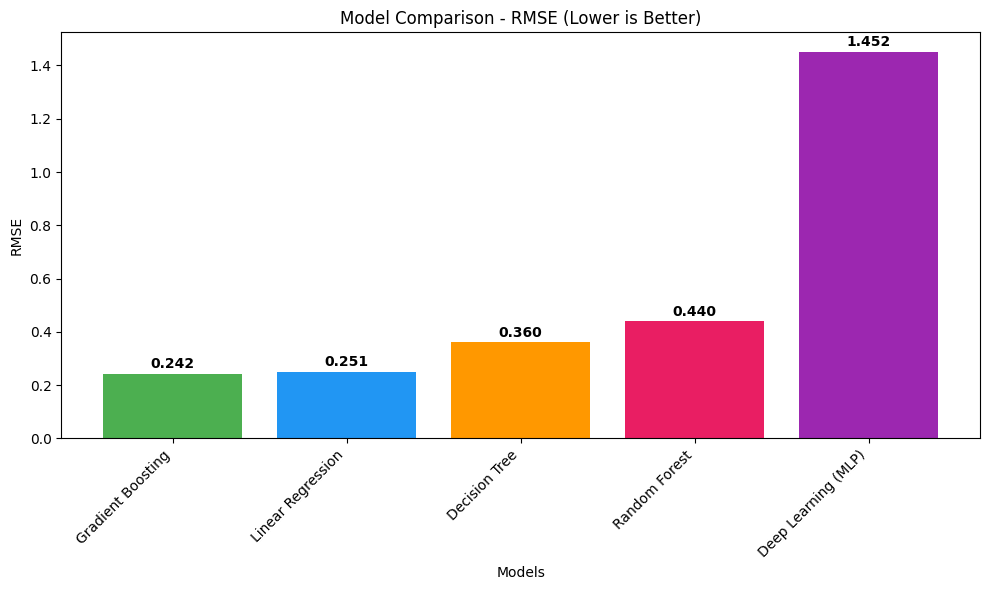

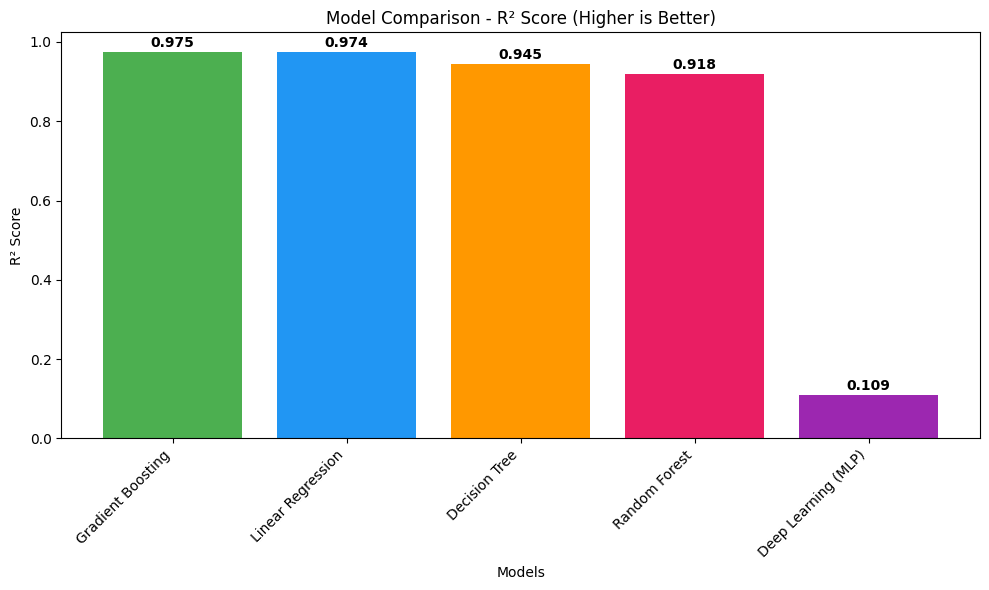


Creating Actual vs Predicted plot for best model: Gradient Boosting


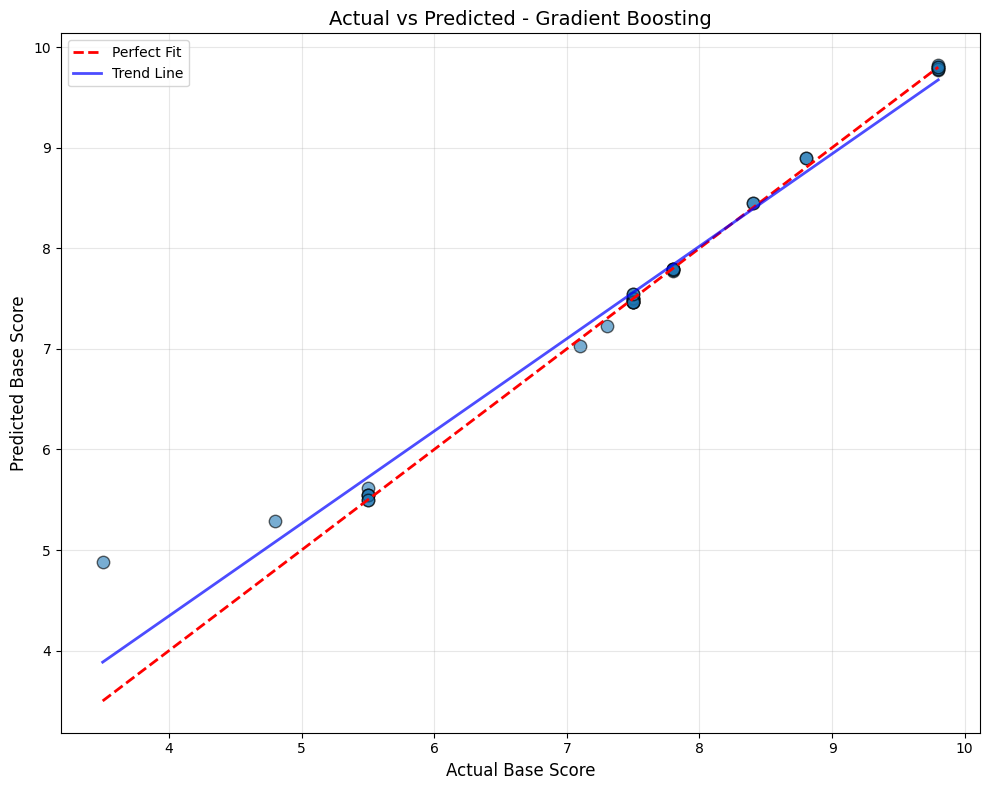

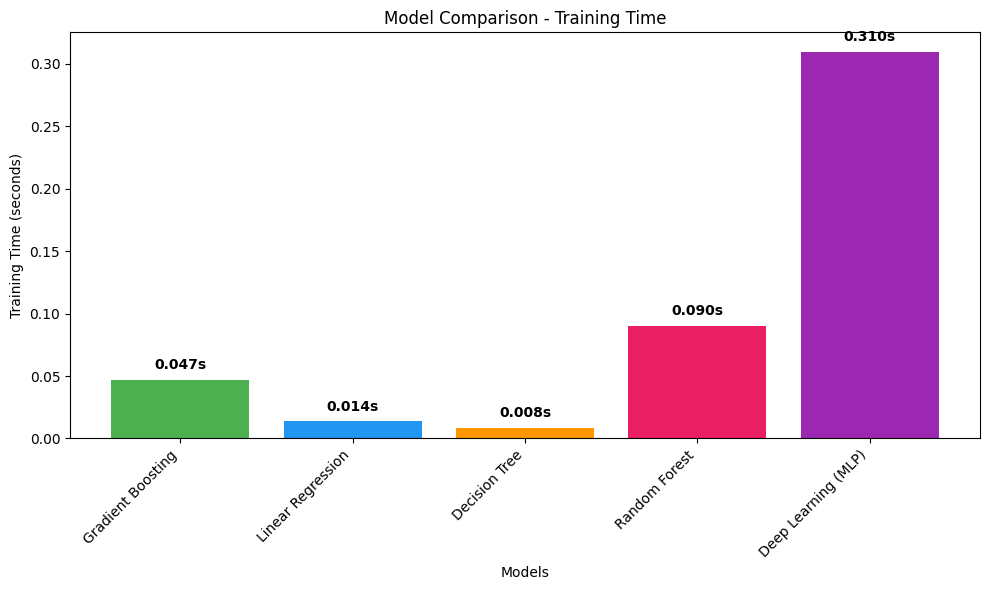


Creating combined subplot figure...


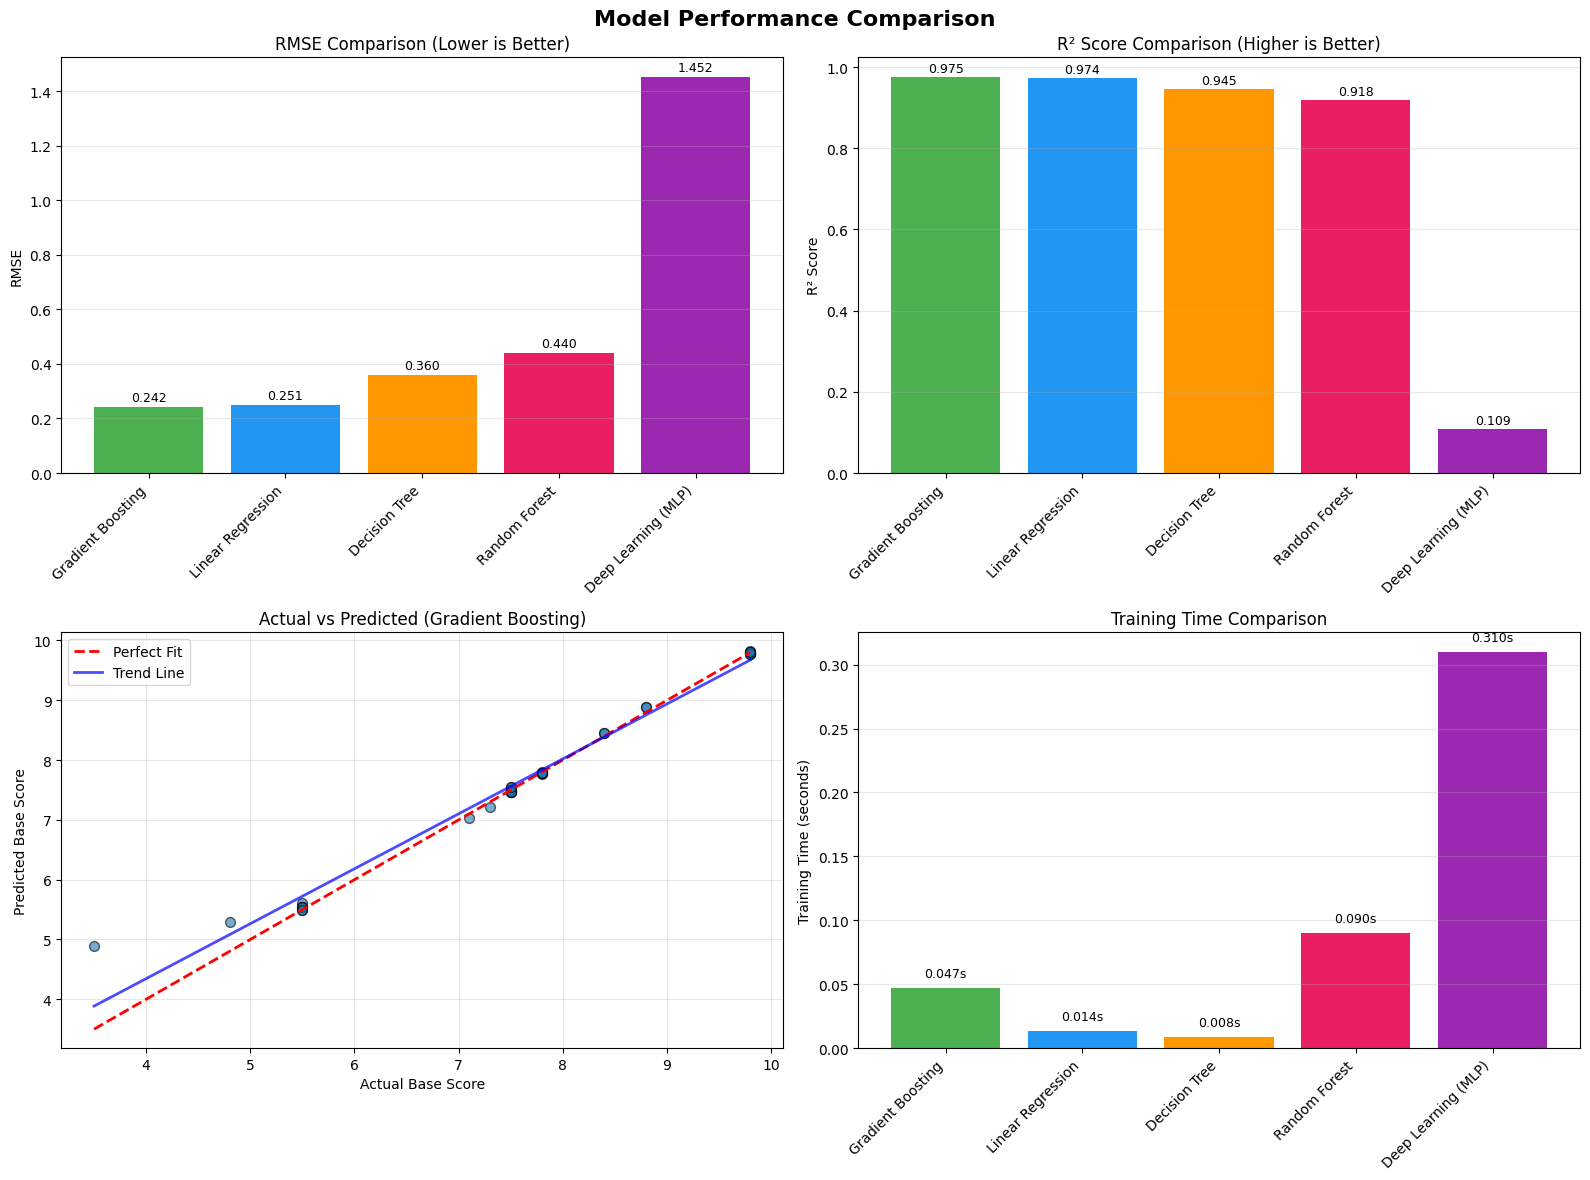


All visualizations created successfully!
Saved files: rmse_comparison.png, r2_comparison.png, actual_vs_predicted.png, training_time_comparison.png, combined_comparison.png


In [21]:
# ==============================
# 9. Visualization - Model Comparison
# ==============================
print("\n" + "="*50)
print("Creating Visualizations")
print("="*50)

# First, let's check what we have in results
print(f"Number of models in results: {len(results)}")
print("Models:", list(results.keys()))

# Create comparison data with all models
comparison_data = []
for name, preds in results.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    comparison_data.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R²": round(r2, 4),
        "Training Time (s)": round(training_times.get(name, 0), 4)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('R²', ascending=False)

print("\nComparison DataFrame:")
print(comparison_df)

# ==============================
# Create Visualizations
# ==============================

# Method 1: Individual plots (more reliable)
print("\nCreating individual plots...")

# Plot 1: RMSE Comparison
plt.figure(figsize=(10, 6))
models_list = comparison_df['Model'].tolist()
rmse_values = comparison_df['RMSE'].tolist()
colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63", "#9C27B0"]

bars = plt.bar(range(len(models_list)), rmse_values, color=colors[:len(models_list)])
plt.xticks(range(len(models_list)), models_list, rotation=45, ha='right')
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE (Lower is Better)")

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, rmse_values)):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: R² Score Comparison
plt.figure(figsize=(10, 6))
r2_values = comparison_df['R²'].tolist()

bars = plt.bar(range(len(models_list)), r2_values, color=colors[:len(models_list)])
plt.xticks(range(len(models_list)), models_list, rotation=45, ha='right')
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score (Higher is Better)")

for i, (bar, value) in enumerate(zip(bars, r2_values)):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Actual vs Predicted (Best Model)
plt.figure(figsize=(10, 8))
best_model_name = comparison_df.iloc[0]['Model']
best_preds = results[best_model_name]

print(f"\nCreating Actual vs Predicted plot for best model: {best_model_name}")

plt.scatter(y_test, best_preds, alpha=0.6, edgecolors='k', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Fit')

# Add regression line
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(y_test.values.reshape(-1, 1), best_preds)
x_range = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_range, lr.predict(x_range.reshape(-1, 1)), 
         'b-', linewidth=2, alpha=0.7, label='Trend Line')

plt.xlabel("Actual Base Score", fontsize=12)
plt.ylabel("Predicted Base Score", fontsize=12)
plt.title(f"Actual vs Predicted - {best_model_name}", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 4: Training Time Comparison
plt.figure(figsize=(10, 6))
times = comparison_df['Training Time (s)'].tolist()

bars = plt.bar(range(len(models_list)), times, color=colors[:len(models_list)])
plt.xticks(range(len(models_list)), models_list, rotation=45, ha='right')
plt.xlabel("Models")
plt.ylabel("Training Time (seconds)")
plt.title("Model Comparison - Training Time")

for i, (bar, value) in enumerate(zip(bars, times)):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(times)*0.02, 
             f'{value:.3f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Alternative: Combined subplot (if individual plots work)
print("\nCreating combined subplot figure...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Subplot 1: RMSE
ax1 = axes[0, 0]
bars1 = ax1.bar(range(len(models_list)), rmse_values, color=colors[:len(models_list)])
ax1.set_xticks(range(len(models_list)))
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.set_ylabel("RMSE")
ax1.set_title("RMSE Comparison (Lower is Better)")
ax1.grid(axis='y', alpha=0.3)
for bar, value in zip(bars1, rmse_values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# Subplot 2: R² Score
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(models_list)), r2_values, color=colors[:len(models_list)])
ax2.set_xticks(range(len(models_list)))
ax2.set_xticklabels(models_list, rotation=45, ha='right')
ax2.set_ylabel("R² Score")
ax2.set_title("R² Score Comparison (Higher is Better)")
ax2.grid(axis='y', alpha=0.3)
for bar, value in zip(bars2, r2_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# Subplot 3: Actual vs Predicted
ax3 = axes[1, 0]
ax3.scatter(y_test, best_preds, alpha=0.6, edgecolors='k', s=50)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Fit')
ax3.plot(x_range, lr.predict(x_range.reshape(-1, 1)), 
         'b-', linewidth=2, alpha=0.7, label='Trend Line')
ax3.set_xlabel("Actual Base Score")
ax3.set_ylabel("Predicted Base Score")
ax3.set_title(f"Actual vs Predicted ({best_model_name})")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Subplot 4: Training Time
ax4 = axes[1, 1]
bars4 = ax4.bar(range(len(models_list)), times, color=colors[:len(models_list)])
ax4.set_xticks(range(len(models_list)))
ax4.set_xticklabels(models_list, rotation=45, ha='right')
ax4.set_ylabel("Training Time (seconds)")
ax4.set_title("Training Time Comparison")
ax4.grid(axis='y', alpha=0.3)
for bar, value in zip(bars4, times):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(times)*0.02, 
             f'{value:.3f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('combined_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll visualizations created successfully!")
print("Saved files: rmse_comparison.png, r2_comparison.png, actual_vs_predicted.png, training_time_comparison.png, combined_comparison.png")

In [22]:
# Plot 2: R² Score Comparison
ax2 = axes[0, 1]
r2_values = comparison_df['R²'].tolist()
bars = ax2.bar(models_list, r2_values, color=colors[:len(models_list)])
ax2.set_xlabel("Models")
ax2.set_ylabel("R² Score")
ax2.set_title("Model Comparison - R² Score")
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(r2_values):
    ax2.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)

# Plot 3: Actual vs Predicted (Best Model)
ax3 = axes[1, 0]
best_model_name = comparison_df.iloc[0]['Model']
best_preds = results[best_model_name]

ax3.scatter(y_test, best_preds, alpha=0.6, edgecolors='k')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Fit')
ax3.set_xlabel("Actual Values")
ax3.set_ylabel("Predicted Values")
ax3.set_title(f"Actual vs Predicted ({best_model_name})")
ax3.legend()

# Plot 4: Training Time Comparison
ax4 = axes[1, 1]
times = comparison_df['Training Time (s)'].tolist()
bars = ax4.bar(models_list, times, color=colors[:len(models_list)])
ax4.set_xlabel("Models")
ax4.set_ylabel("Training Time (seconds)")
ax4.set_title("Model Comparison - Training Time")
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(times):
    ax4.text(i, v + max(times)*0.02, f"{v:.3f}s", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>


Feature Importance Analysis (Gradient Boosting)

Top 10 Important Features:
    Feature  Importance
          I    0.340643
         AV    0.261319
          C    0.202885
          A    0.085174
         PR    0.076994
         UI    0.017831
        cwe    0.008149
         AC    0.005559
       year    0.001446
vuln_status    0.000000


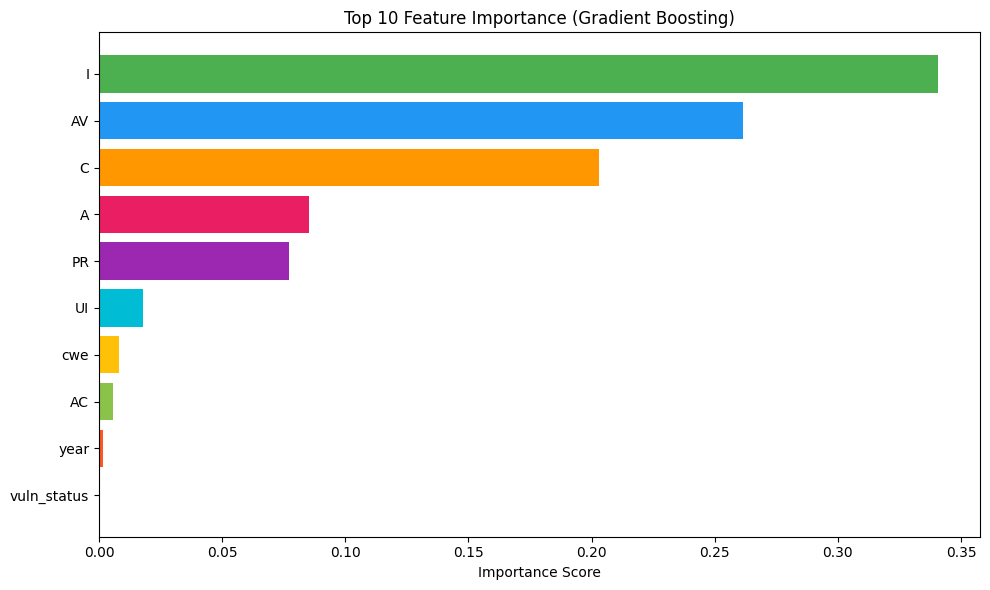

In [23]:
# ==============================
# 10. Feature Importance (Gradient Boosting)
# ==============================
print("\n" + "="*50)
print("Feature Importance Analysis (Gradient Boosting)")
print("="*50)

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'].values, 
         color=['#4CAF50', '#2196F3', '#FF9800', '#E91E63', '#9C27B0',
                '#00BCD4', '#FFC107', '#8BC34A', '#FF5722', '#3F51B5'])
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


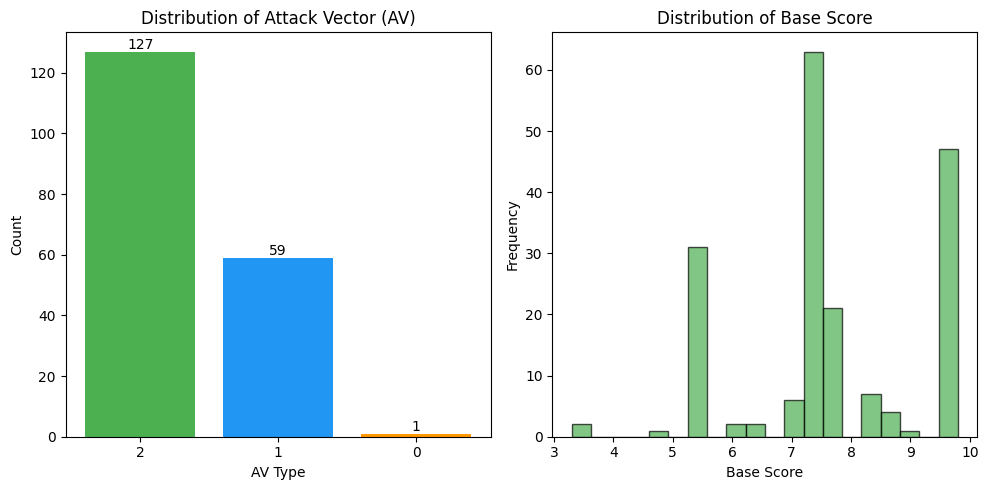


Saving Models
✓ Saved: gradient_boosting_model.pkl
✓ Saved: random_forest_model.pkl
✓ Saved: deep_learning_mlp_model.pkl
✓ Saved: model_comparison_results.csv


In [24]:
# ==============================
# 11. Distribution of Attack Vector
# ==============================
plt.figure(figsize=(10, 5))

# Subplot 1: Attack Vector Distribution
plt.subplot(1, 2, 1)
av_counts = df['AV'].value_counts()
colors_av = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]
plt.bar(av_counts.index.astype(str), av_counts.values, color=colors_av[:len(av_counts)])
plt.title("Distribution of Attack Vector (AV)")
plt.xlabel("AV Type")
plt.ylabel("Count")
for i, v in enumerate(av_counts.values):
    plt.text(i, v + 1, str(v), ha='center')

# Subplot 2: Base Score Distribution
plt.subplot(1, 2, 2)
plt.hist(df['base_score'], bins=20, edgecolor='black', color='#4CAF50', alpha=0.7)
plt.title("Distribution of Base Score")
plt.xlabel("Base Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================
# 12. Save Models
# ==============================
print("\n" + "="*50)
print("Saving Models")
print("="*50)

# Save traditional ML models
joblib.dump(models['Gradient Boosting'], "gradient_boosting_model.pkl")
print("✓ Saved: gradient_boosting_model.pkl")

joblib.dump(models['Random Forest'], "random_forest_model.pkl")
print("✓ Saved: random_forest_model.pkl")

# Save deep learning model
joblib.dump(dl_model, "deep_learning_mlp_model.pkl")
print("✓ Saved: deep_learning_mlp_model.pkl")

# Save comparison results
comparison_df.to_csv("model_comparison_results.csv", index=False)
print("✓ Saved: model_comparison_results.csv")

In [25]:
# ==============================
# 13. Final Summary
# ==============================
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"\nDataset Statistics:")
print(f"  Total samples: {len(df)}")
print(f"  Features: {X.shape[1]}")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Base Score Range: {y.min():.1f} - {y.max():.1f}")

print(f"\nBest Performing Model: {best_model_name}")
print(f"  R² Score: {r2_score(y_test, best_preds):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, best_preds)):.4f}")

print("\nDeep Learning Model Details:")
print("  Type: Artificial Neural Network (MLP Regressor)")
print("  Architecture: Input → 128 → 64 → 32 → Output")
print("  Activation Function: ReLU")
print("  Optimizer: Adam")
print("  Learning Rate: 0.001")
print("  Max Iterations: 500")
print(f"  Training Time: {dl_duration:.4f} seconds")

print("\n" + "="*50)
print("Training Complete! All models saved successfully.")
print("="*50)


FINAL SUMMARY

Dataset Statistics:
  Total samples: 187
  Features: 11
  Training samples: 149
  Test samples: 38
  Base Score Range: 3.3 - 9.8

Best Performing Model: Gradient Boosting
  R² Score: 0.9753
  RMSE: 0.2418

Deep Learning Model Details:
  Type: Artificial Neural Network (MLP Regressor)
  Architecture: Input → 128 → 64 → 32 → Output
  Activation Function: ReLU
  Optimizer: Adam
  Learning Rate: 0.001
  Max Iterations: 500
  Training Time: 0.3098 seconds

Training Complete! All models saved successfully.
